In [322]:
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [323]:
# trasform the csv file to a dataframe 
df = pd.read_csv('C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/loan_data [Task 1-3] - loan_data.csv')

In [324]:
# print the first five rows of the data
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [325]:
# drop the Loan Id columns because it is unque throught so it won't help us in our model
# or we can make it an index 
df = df.set_index('Loan_ID')
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [326]:
# split the data into target and features 
target = 'Loan_Status'
y = df[target]
X = df.drop(columns=target)

In [327]:
# To esnure we have splitted our data the right way I print the shapes of target and features 
print(y.shape)
print(X.shape)

(614,)
(614, 11)


TASK 1


1a. Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [328]:
# split the data into test and train set 
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [329]:
# print out the shapes to make sure I have splitted the datset right 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(491, 11)
(491,)
(123, 11)
(123,)


In [330]:
# I will first clean the data 
# I diplayed the datatypes for the columns 
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [331]:
# According to the dependets the column in the df should be numeric (number int)
# however when we display it it says it is an object
# Lets display the unique or value counts to find iut what is causing it
df['Dependents'].value_counts()

# According to the diction this is number of depedants and this is an ordinal column so 
# The + is on 3 turns the column in to datatype of objet I will not change because it change the meaning
# # 3+ means the the loaner has either 3 or morethan so I will treat this as an ordinal columns and transform it

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

1b. Create a model pipeline (for feature transformations)

In [332]:
# identify ordinal columns in features
ordinal_features = ['Dependents']
# define a transformation Pipeline for the ordinal features 
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])



In [333]:
# Identify categorical columns
nominal_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', ]
#define transformation pipeline for the categorical features
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="MISSING")),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [334]:
# Identify numerical columns 
numerical_features = ['Credit_History', 'Loan_Amount_Term', 'LoanAmount', 'CoapplicantIncome', 'ApplicantIncome']
# Define the tranformation pipeline for the numerical features
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [335]:
# define tuples for the pipelines created and attributes to them 
ordinal_tuples = ('ordinal', ordinal_pipeline, ordinal_features)
nominal_tuples = ('nominal', nominal_pipeline, nominal_features)
numeric_tuples = ('numeric', numerical_pipeline, numerical_features)

In [336]:
# I created a columns tranfromer to inlcude all my pipelines tuples 
column_transformer = ColumnTransformer(transformers=[
    ordinal_tuples,
    nominal_tuples,
    numeric_tuples
]) 

In [337]:
# fit and transform the X_train dataset to the column_trnsformer to make it ready for ready for the model. 
X_train_transformed = column_transformer.fit_transform(X_train)

In [338]:
# transform  the fitted and tranformed X_train set to dataframe 
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_transformer.get_feature_names_out())
X_train_transformed.head()

,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.199099e-16,0.295122,1.349134,0.180667,0.083915
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.205624,0.385430,-0.429338
2,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,0.710987,0.005831,0.126095
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.240432,0.464185,-0.576970
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-2.434254e+00,0.295122,-0.588512,-0.528127,-0.225522


In [339]:
# lets print the shape to confirm we are using tht right train set 
X_train_transformed.shape

(491, 20)

1. Start by building and evaluating a default decision tree model using appropriate metrics and a confusion matrix.

In [340]:
# we instatiate the our defalut decision tree classifier 
default_dec_tree =  DecisionTreeClassifier(random_state=42)

In [341]:
# Fit the default model 
default_dec_tree.fit(X_train_transformed, y_train)

DecisionTreeClassifier(random_state=42)

In [342]:
# test the model 
# Before I test the model we need to tranform the test set too, to make the data clean and suitable the model 
# However since I have already created the Pipelines lets transform the test set immediately 
X_test_transformed = column_transformer.fit_transform(X_test)
# I transform the array to dataframe in order to capture feature names created during the encoding
X_test_transformed = pd.DataFrame(X_test_transformed, columns=column_transformer.get_feature_names_out())
# print out the first three rows and the shpe to make sure am using the right test set 
X_test_transformed.head(3)


,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.469058,0.212595,1.233336,-0.906211,0.603713
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.212595,-0.095371,-0.906211,-0.103326
2,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.469058,0.212595,0.284259,0.029939,-0.124509


In [343]:
# to make sure am using the right test set let me print the shape
X_test_transformed.shape

(123, 20)

In [ ]:
# Then now I can test model 
# I will test the default model using the test set 
default_test_pred =  default_dec_tree.predict(X_test_transformed)
default_test_pred

array(['Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N',
       'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'N'], dtype=object)

In [ ]:
# Lets me now evaluate the default model using classification report  and confusion matrix
# Let me start with classification report 
# Here I am comparing the actual test values with what the model predicted 
print(classification_report(y_test, default_test_pred))

              precision    recall  f1-score   support

           N       0.49      0.51      0.50        43
           Y       0.73      0.71      0.72        80

    accuracy                           0.64       123
   macro avg       0.61      0.61      0.61       123
weighted avg       0.65      0.64      0.64       123



In [ ]:
# Then I print out the confusion_matrix still in comparison of the actual test sest target values and what the model predicted
confusion_matrix(y_test, default_test_pred)

array([[22, 21],
       [23, 57]])

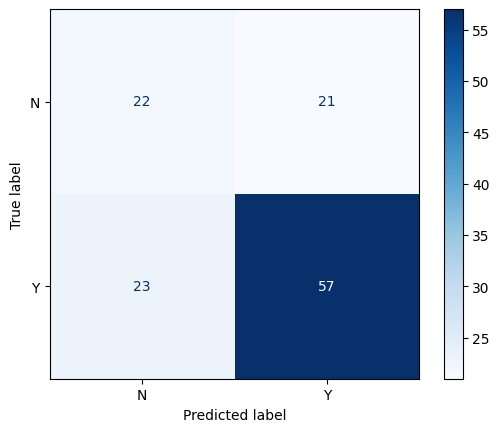

In [367]:
# let me now display it the cinfusion matrix in image form
ConfusionMatrixDisplay.from_predictions(y_test, default_test_pred, cmap="Blues")

Task1. 2. Then, use GridSearchCV to tune the model. Be sure to change the default scoring to "recall_macro" when you instantiate the GridSearch.  (Be sure to explain the GridSearchCV technique)

Grid Search Cross-Validation (GridSearchCV) is a hyperparameter tuning technique in machine learning that helps find the best combination of hyperparameters for a model by exhaustively searching through a specified parameter grid. It evaluates a model's performance for each combination of parameters, typically using cross-validation to get an unbiased estimate of performance.


In [348]:
# Before I instatiate the Grid search 
# I need instatiate a model to be used 
# I need to define a dictionary of parameters (hyperparameters) to be used in the GridSearchCV

# model 
model_dt = DecisionTreeClassifier()

# parameters for tuning 
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_leaf_nodes': [None, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}

In [349]:
#lets instatiate the grid search cv to tune model
# The Grid search cv has different attributes
# DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2)
grid_search = GridSearchCV(
    estimator=model_dt,      # atrribute for the model tobe used
    param_grid=param_grid,   #attribute for thr parameters to tune the model with different values
    scoring="recall_macro",  # scoring metrics (Actually good for imbalanced malticlass problems)
    cv=5,                    # cross validation (we are using 5 here)
    verbose=1,               # to diplay the progress
    n_jobs=-1,               # to utelize all my cpu cores 
    return_train_score=True  # store training scores in cv results
)

In [350]:
# transform  the fitted and tranformed X_train set to dataframe 
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_transformer.get_feature_names_out())
X_train_transformed.head()

,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.199099e-16,0.295122,1.349134,0.180667,0.083915
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.205624,0.385430,-0.429338
2,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,0.710987,0.005831,0.126095
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.240432,0.464185,-0.576970
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-2.434254e+00,0.295122,-0.588512,-0.528127,-0.225522


In [351]:
# Lets fit the the data with the model 
# I am going to use my x training data set transformed data 
grid_search.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'max_leaf_nodes': [None, 10, 20, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='recall_macro', verbose=1)

In [352]:
# I found out best model from grid search
best_model = grid_search.best_estimator_
best_model

DecisionTreeClassifier(criterion='entropy', max_depth=10, max_leaf_nodes=10,
                       min_samples_leaf=2, min_samples_split=5)

Task 1, 3. Visualize the trees from both the default and the tuned model versions.

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.44952256944444446, 0.96875, 'numeric__Credit_History <= -1.217\ngini = 0.423\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.08333333333333333, 0.90625, 'numeric__CoapplicantIncome <= 2.028\ngini = 0.157\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.2664279513888889, 0.9375, 'True  '),
 Text(0.05555555555555555, 0.84375, 'numeric__ApplicantIncome <= -0.2\ngini = 0.136\nsamples = 68\nvalue = [63, 5]\nclass = N'),
 Text(0.03333333333333333, 0.78125, 'numeric__Loan_Amount_Term <= -1.501\ngini = 0.045\nsamples = 43\nvalue = [42, 1]\nclass = N'),
 Text(0.022222222222222223, 0.71875, 'numeric__ApplicantIncome <= -0.499\ngini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = N'),
 Text(0.011111111111111112, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Y'),
 Text(0.03333333333333333, 0.65625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = N'),
 Text(0.044444444444444446, 0.71875, 'gini = 0.0\nsamples = 36\nvalue = [36, 0]\nclass = N'),
 Text(0.0777777777777

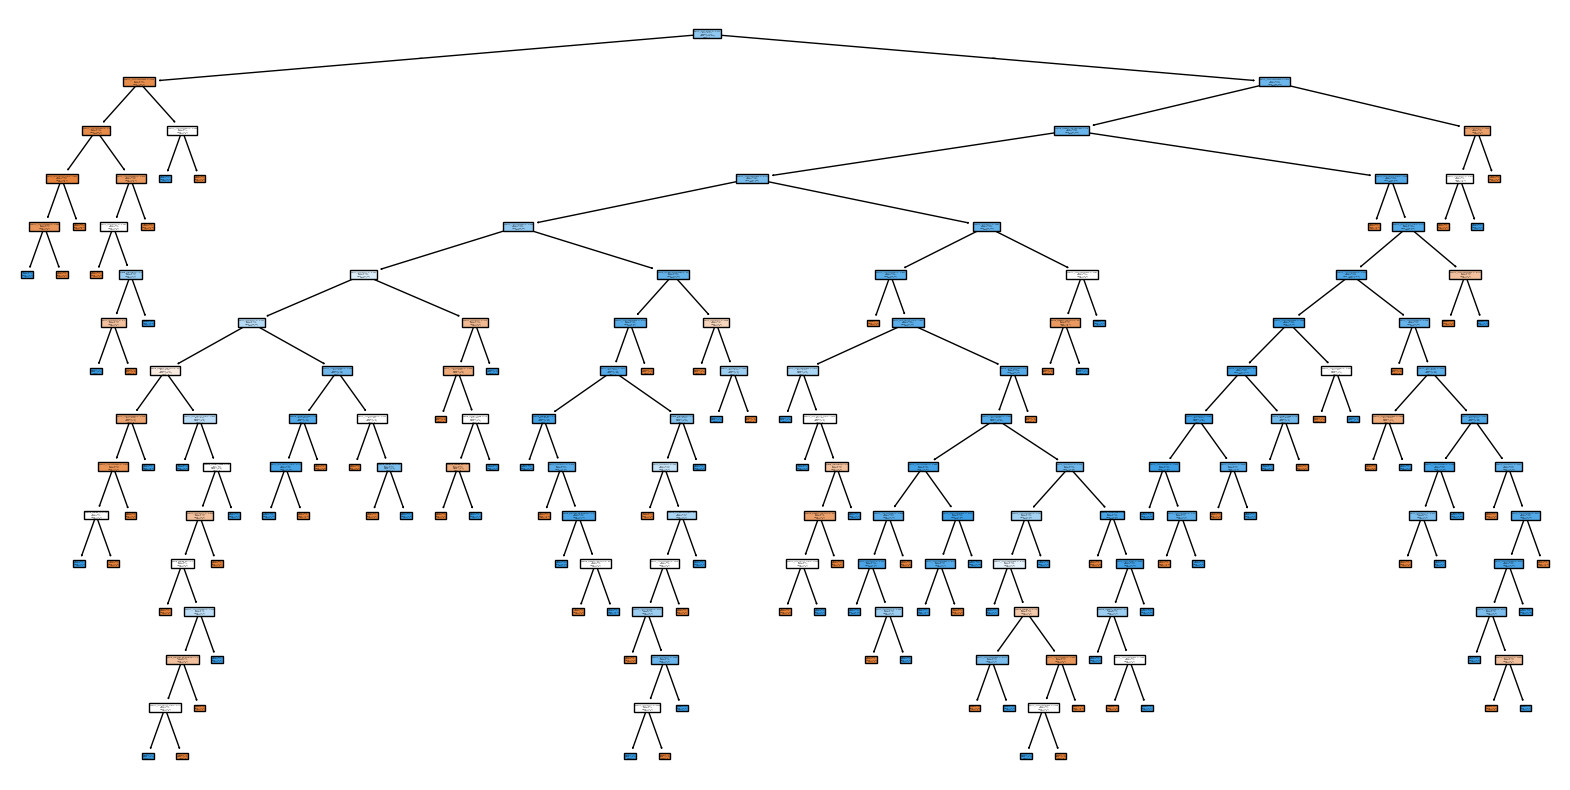

In [359]:
# here am visualizing the default model 
plt.figure(figsize=(20,10))
tree.plot_tree(default_dec_tree, feature_names=X_train_transformed.columns, class_names=y_train, filled=True)

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.5384615384615384, 0.9375, 'numeric__Credit_History <= -1.217\nentropy = 0.885\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.46153846153846156, 0.8125, 'entropy = 0.422\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.5, 0.875, 'True  '),
 Text(0.6153846153846154, 0.8125, 'nominal__Property_Area_Semiurban <= 0.5\nentropy = 0.726\nsamples = 421\nvalue = [85, 336]\nclass = Y'),
 Text(0.5769230769230769, 0.875, '  False'),
 Text(0.46153846153846156, 0.6875, 'numeric__CoapplicantIncome <= 3.935\nentropy = 0.816\nsamples = 253\nvalue = [64.0, 189.0]\nclass = Y'),
 Text(0.38461538461538464, 0.5625, 'numeric__CoapplicantIncome <= 1.173\nentropy = 0.802\nsamples = 250\nvalue = [61, 189]\nclass = Y'),
 Text(0.3076923076923077, 0.4375, 'numeric__CoapplicantIncome <= 1.089\nentropy = 0.818\nsamples = 240\nvalue = [61, 179]\nclass = Y'),
 Text(0.23076923076923078, 0.3125, 'numeric__CoapplicantIncome <= -0.211\nentropy = 0.808\nsamples = 238\nvalue = [59, 179]\nclass = Y'),
 T

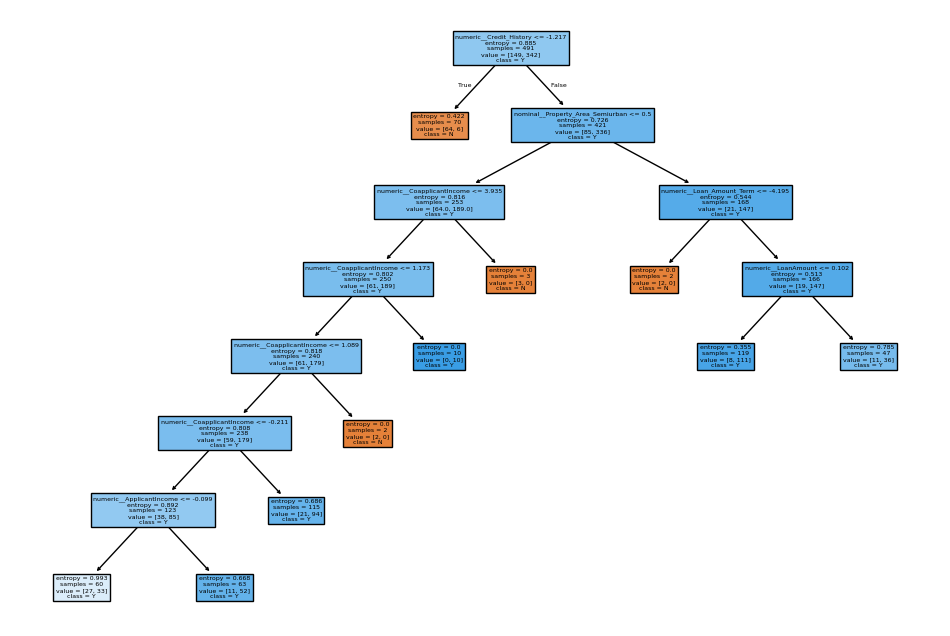

In [357]:
# Here I am visualizing the best model from the grid search view 
plt.figure(figsize=(12,8))
tree.plot_tree(best_model, feature_names=X_train_transformed.columns, class_names=y_train,  filled=True)

Task 1. 4.Make sure you have evaluated both the default and the tuned versions using appropriate metrics and a confusion matrix.

In [363]:
# I have already evaluated the default model model 
# here I am going to evaluate the tuned version (best model)
# I will start by predicting using the best model 
best_model_pred = best_model.predict(X_test_transformed)
best_model_pred

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [364]:
# Then now evaluate the version model  using the actual target values of test set and the values predicted by the tuned model
# using confusion report
print(classification_report(y_test, best_model_pred))

              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [ ]:
# Let me display the confusion matrix 
confusion_matrix(y_test, best_model_pred)

array([[18, 25],
       [ 1, 79]])

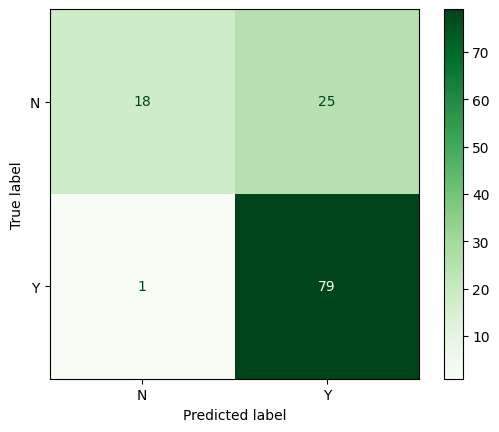

In [368]:
# let me display the confusion matrix 
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred, cmap="Greens")

Task1. 5.Which combination of hyperparameters led to the best-tuned model?

In [370]:
# to find the best parameters in the grid search that made the best tuned model we will use  .best_params_ 
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'max_leaf_nodes': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [371]:
# best_param = {
#     'criterion': 'entropy', 
#     'max_depth': 10, 
#     'max_leaf_nodes': 10, 
#     'min_samples_leaf': 2, 
#     'min_samples_split': 5
# }

In [ ]:
# Let me display the parameters of the default model  
param = default_dec_tree.get_params()
print(param)

# 'ccp_alpha': 0.0, 
# 'class_weight': None, 
# 'criterion': 'gini', 
# 'max_depth': None, 
# 'max_features': None, 
# 'max_leaf_nodes': None, 
# 'min_impurity_decrease': 0.0, 
# 'min_samples_leaf': 1, 
# 'min_samples_split': 2, 
# 'min_weight_fraction_leaf': 0.0, 
# 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
